**1.  Setup and Importing Libraries**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_circles, make_moons
from sklearn.preprocessing import StandardScaler

*   **`numpy`:** For numerical operations, especially creating and working with arrays.
*   **`matplotlib.pyplot`:** For creating visualizations.
*   **`sklearn.datasets`:** To generate synthetic datasets (like moons and circles) that are great for demonstrating clustering.
*   **`sklearn.preprocessing.StandardScaler`:** To standardize features (important for distance-based algorithms like DBSCAN).
*   **`sklearn.cluster.DBSCAN`:** The DBSCAN algorithm implementation.

**2.  Generating and Visualizing the Data**

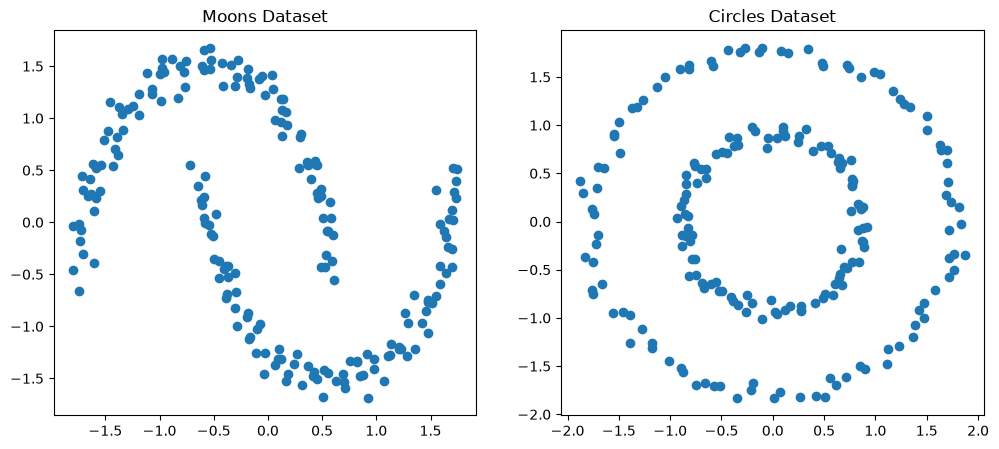

In [2]:
# Generate 'moons' dataset
X_moons, y_moons = make_moons(n_samples=200, noise=0.05, random_state=0)

# Generate 'circles' dataset
X_circles, y_circles = make_circles(
    n_samples=200, noise=0.03, factor=0.5, random_state=0
)

# Standardize the data
X_moons = StandardScaler().fit_transform(X_moons)
X_circles = StandardScaler().fit_transform(X_circles)

# Visualize the datasets
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1])
plt.title("Moons Dataset")

plt.subplot(1, 2, 2)
plt.scatter(X_circles[:, 0], X_circles[:, 1])
plt.title("Circles Dataset")

plt.show()

*   **`make_moons` and `make_circles`:** Create two-dimensional datasets with distinct shapes.
*   **`StandardScaler`:** Rescales the data to have zero mean and unit variance. This often helps improve the performance of DBSCAN.
*   **Visualization:** The `scatter` plots show the generated datasets before clustering.

**3.  Understanding DBSCAN Parameters**

Before running DBSCAN, let's explain the key parameters:

*   **`eps` (epsilon):** This is the radius within which we search for neighboring points. If a point has at least `min_samples` neighbors within a radius of `eps`, it's considered a core point.
*   **`min_samples`:** The minimum number of points required to form a dense cluster (including the point itself).

**4.  Applying DBSCAN to the 'Moons' Dataset**

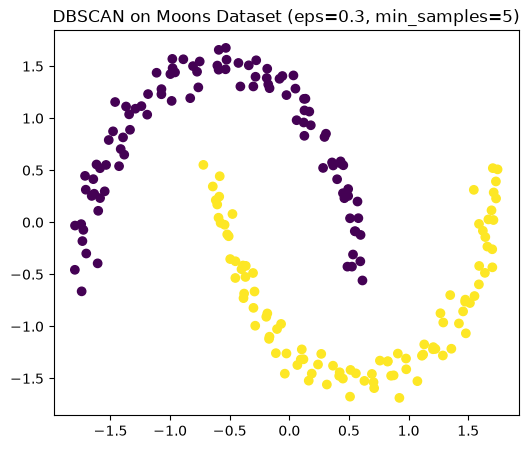

In [3]:
# Apply DBSCAN to the moons dataset
dbscan_moons = DBSCAN(eps=0.3, min_samples=5)
clusters_moons = dbscan_moons.fit_predict(X_moons)

# Visualize the clusters found by DBSCAN
plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=clusters_moons, cmap="viridis")
plt.title("DBSCAN on Moons Dataset (eps=0.3, min_samples=5)")
plt.show()

# Explanation of cluster labels:
# -1 represents noise points (points that are not part of any cluster)
# 0, 1, 2, ... represent different clusters

*   **`DBSCAN(eps=0.3, min_samples=5)`:** Creates a DBSCAN object with specified parameters.
*   **`fit_predict(X_moons)`:** Fits the DBSCAN model to the data and returns cluster labels for each point.
*   **Visualization:** The `scatter` plot now colors the points based on their assigned cluster labels. This visually shows how DBSCAN identified the two crescent-shaped clusters and any noise points.

**5.  Exploring the Effect of `eps`**

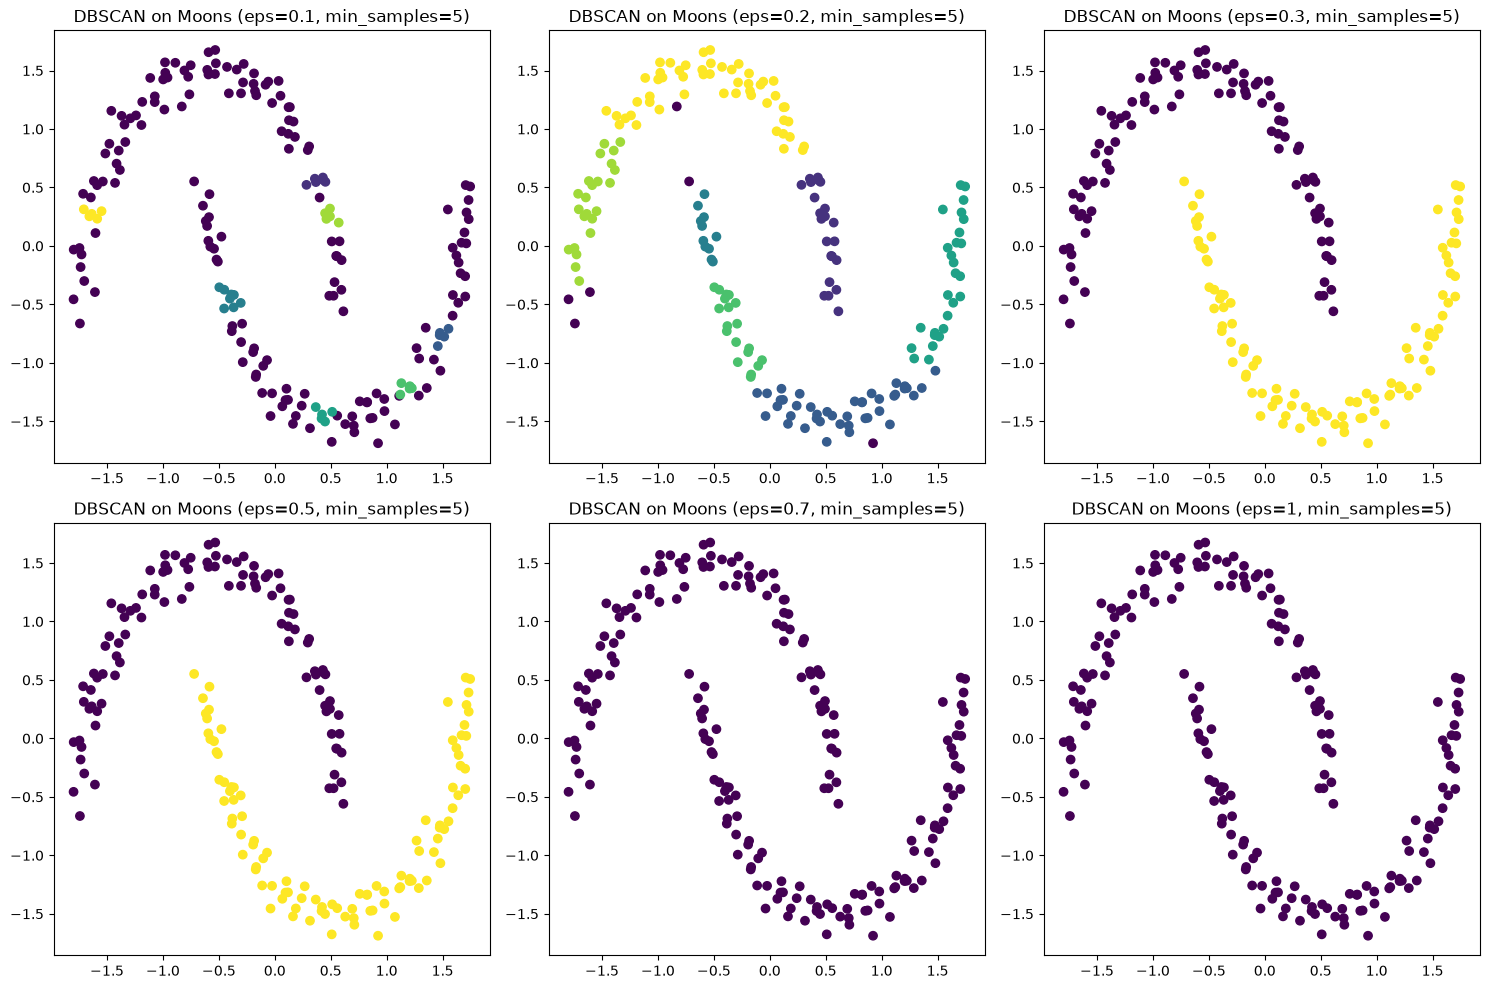

In [4]:
# Varying eps and visualizing the results
eps_values = [0.1, 0.2, 0.3, 0.5, 0.7, 1]

plt.figure(figsize=(15, 10))

for i, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    clusters = dbscan.fit_predict(X_moons)

    plt.subplot(2, 3, i + 1)
    plt.scatter(X_moons[:, 0], X_moons[:, 1], c=clusters, cmap="viridis")
    plt.title(f"DBSCAN on Moons (eps={eps}, min_samples=5)")

plt.tight_layout()
plt.show()

*   **Loop through `eps` values:** We run DBSCAN with different `eps` values to see how it affects the results.
*   **Visualization:** The subplots demonstrate that:
    *   A very small `eps` can result in many noise points (as points might not have enough neighbors within that small radius).
    *   A larger `eps` can merge clusters that should ideally be separate.
    *   Finding the right `eps` is crucial for good clustering.

**6.  Exploring the Effect of `min_samples`**

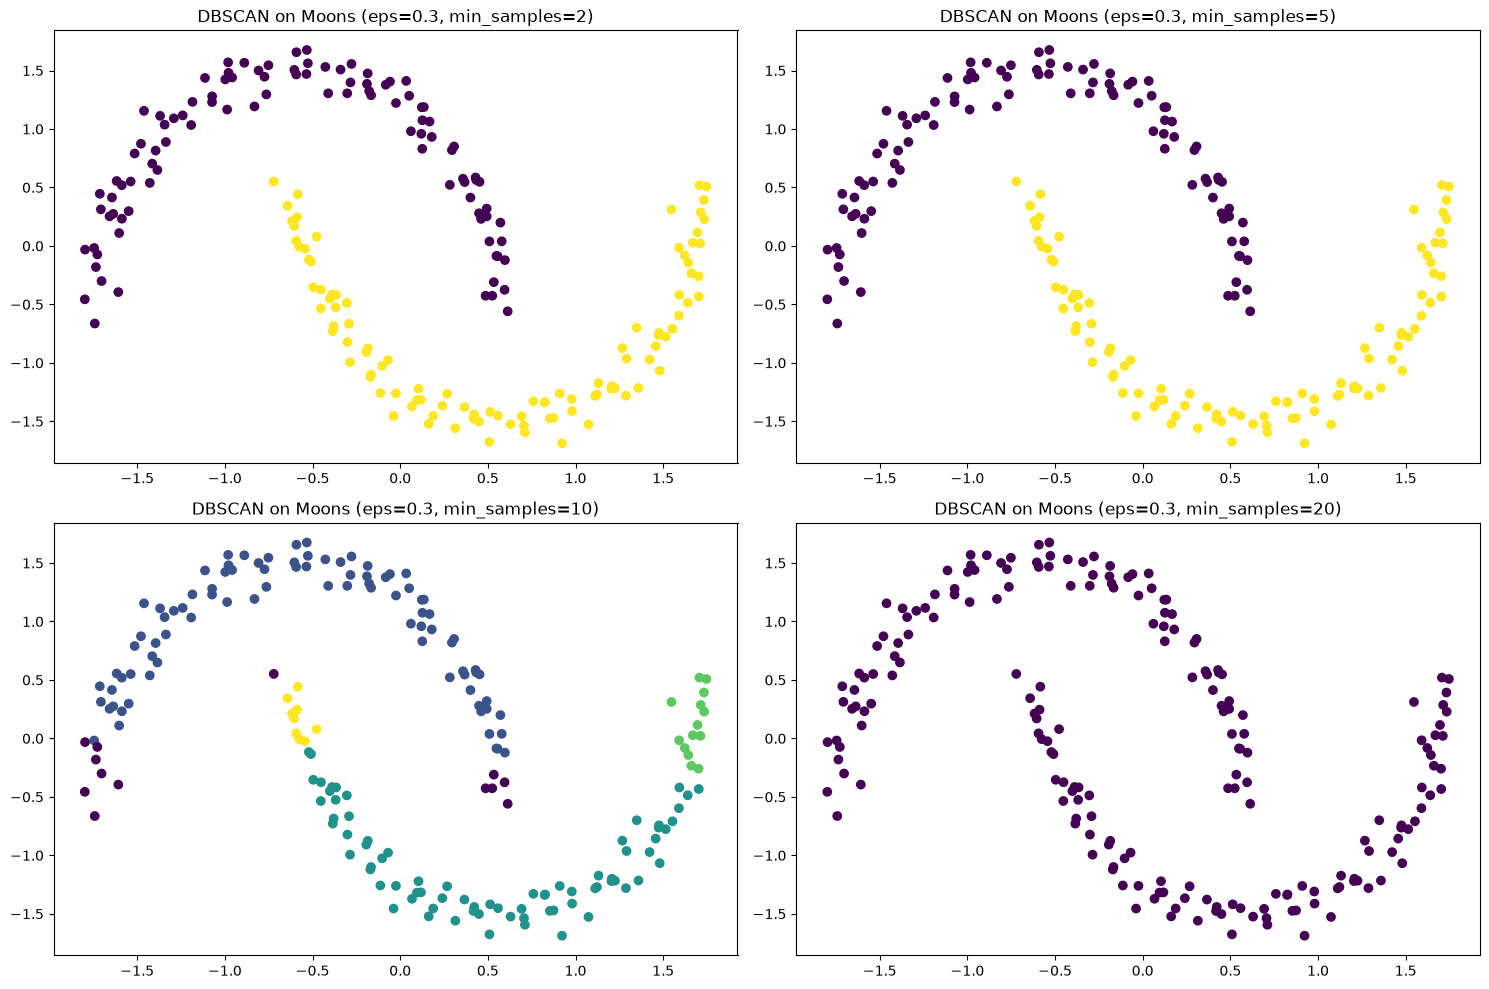

In [5]:
# Varying min_samples and visualizing the results
min_samples_values = [2, 5, 10, 20]

plt.figure(figsize=(15, 10))

for i, min_samples in enumerate(min_samples_values):
    dbscan = DBSCAN(eps=0.3, min_samples=min_samples)
    clusters = dbscan.fit_predict(X_moons)

    plt.subplot(2, 2, i + 1)
    plt.scatter(X_moons[:, 0], X_moons[:, 1], c=clusters, cmap="viridis")
    plt.title(f"DBSCAN on Moons (eps=0.3, min_samples={min_samples})")

plt.tight_layout()
plt.show()

*   **Loop through `min_samples`:** We run DBSCAN with different `min_samples` values.
*   **Visualization:** The subplots show that:
    *   A very small `min_samples` can lead to many small clusters (and potentially less noise).
    *   A larger `min_samples` requires denser regions to form clusters, resulting in potentially more noise points.

**7.  Applying DBSCAN to the 'Circles' Dataset**

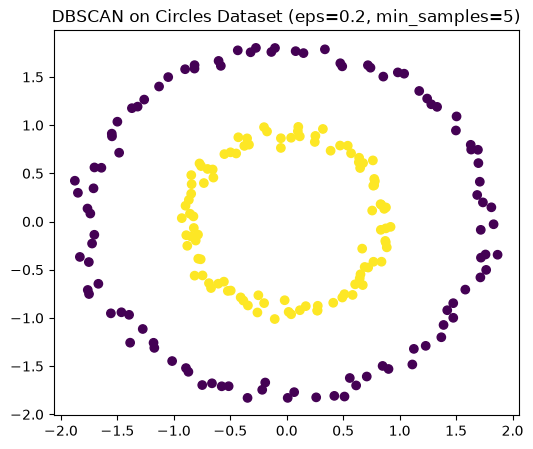

In [6]:
# Apply DBSCAN to the circles dataset
dbscan_circles = DBSCAN(eps=0.4, min_samples=5)
clusters_circles = dbscan_circles.fit_predict(X_circles)

# Visualize the clusters
plt.figure(figsize=(6, 5))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=clusters_circles, cmap="viridis")
plt.title("DBSCAN on Circles Dataset (eps=0.2, min_samples=5)")
plt.show()

*   We apply DBSCAN to the circles dataset using appropriate parameters (you might need to experiment to find good values).
*   The visualization demonstrates that DBSCAN can successfully identify the two circular clusters.

**8. Core, Border and Noise Points Visualization**

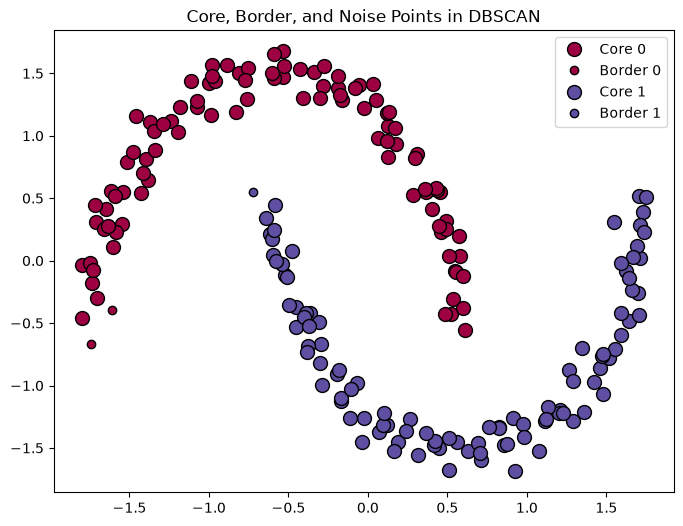

In [7]:
# Fit DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
clusters = dbscan.fit_predict(X_moons)

# Get core sample indices
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# Identify core, border, and noise points
labels = dbscan.labels_
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))

for k, col in zip(unique_labels, colors, strict=True):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    # Plot core points
    xy = X_moons[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=10,
        label=f"Core {k}",
    )

    # Plot border points
    xy = X_moons[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
        label=f"Border {k}",
    )

plt.title("Core, Border, and Noise Points in DBSCAN")
plt.legend()
plt.show()

*   **`core_samples_mask`:** Identifies the core points.
*   **Plotting Logic:** It differentiates and plots core points with a larger size and border points with a smaller size. Noise points are marked in black.

This detailed code with visualizations will help your students understand the DBSCAN algorithm, how its parameters work, and how it can be used to identify clusters of varying shapes and densities. Please let me know if you have any other questions.